# crypto latency

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## configure

In [2]:
BASE_DIR = "files"
INPUT_XLSX = f"{BASE_DIR}/hex.xlsx"

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

In [3]:
def get_df(file):
    df = pd.read_excel(file)
    return df
original_df = get_df(INPUT_XLSX)

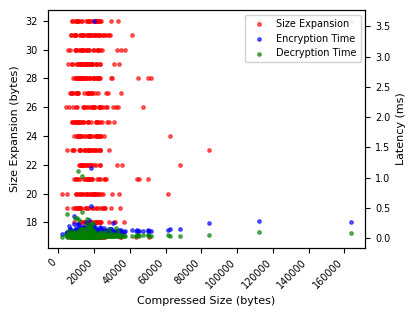

In [ ]:
def ase_overhand(df):
    df = df.sort_values("compressed_size")
    
    expansion = df["encrypted_size"] - df["compressed_size"]
    
    # latency
    enc_time = df["text_encrypt_time"] * 1000
    dec_time = df["text_decrypt_time"] * 1000
    
    fig, ax1 = plt.subplots(figsize=(4.2, 3.2))
    
    # 左轴：size expansion
    ax1.scatter(df["compressed_size"], expansion, s=6, alpha=0.6, color="red", label="Size Expansion")
    ax1.set_xlabel("Compressed Size (bytes)")
    ax1.set_ylabel("Size Expansion (bytes)")
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 右轴：latency
    ax2 = ax1.twinx()
    ax2.scatter(df["compressed_size"], enc_time, s=6, alpha=0.6, color="blue", label="Encryption Time")
    ax2.scatter(df["compressed_size"], dec_time, s=6, alpha=0.6, color="green", label="Decryption Time")
    ax2.set_ylabel("Latency (ms)")
    
    # 合并图例
    # 方法1：合并两个轴的图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)
    
    # 方法2：如果想让图例放在右上角（不遮挡数据）
    # ax2.legend(loc='upper right', framealpha=0.9)
    
    # plt.title("ASE Encryption Overhead Analysis")
    plt.tight_layout()
    plt.savefig(
        "assets/aes-latency.pdf",
        bbox_inches="tight"
    )
    plt.show()
ase_overhand(original_df)

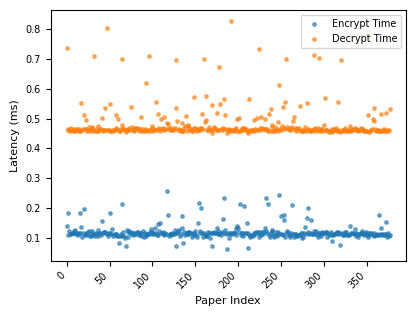

In [7]:
def rsa_overhand(df):
    plt.figure(figsize=(4.2,3.2))
    plt.scatter(df.index, df["key_encrypt_time"]*1000, s=6, alpha=0.6, label="Encrypt Time")
    plt.scatter(df.index, df["key_decrypt_time"]*1000, s=6, alpha=0.6, label="Decrypt Time")
    plt.ylabel("Latency (ms)")
    plt.xlabel("Paper Index")
    
    # 使用 setp 设置旋转和对齐
    plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')
    
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        "assets/rsa-latency.pdf",
        bbox_inches="tight"
    )
    plt.show()
rsa_overhand(original_df)